<a href="https://colab.research.google.com/github/KarthikK04042006/DAV_LAB/blob/main/DAV_LAB_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
/content/drive/MyDrive/uber-raw-data-aug14.csv

Text(0.5, 1.0, 'Uber Pickups by Day of Week and Hour of Day')

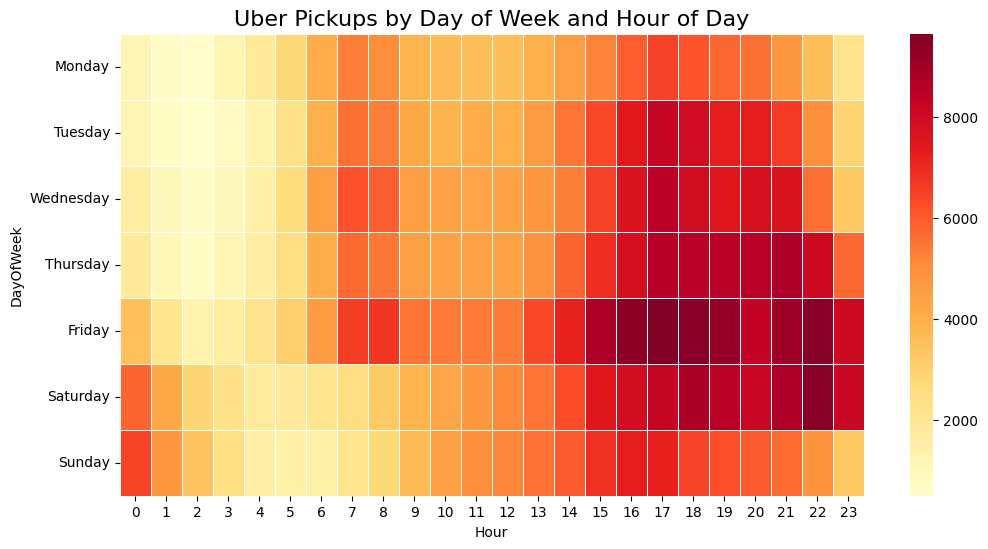

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/content/drive/MyDrive/uber-raw-data-aug14.csv')
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['DayOfWeek'] = df['Date/Time'].dt.day_name()
df['Hour'] = df['Date/Time'].dt.hour
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df.pivot_table(index='DayOfWeek', columns='Hour', values='Date/Time', aggfunc='count')
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df.pivot_table(index='DayOfWeek', columns='Hour', values='Date/Time', aggfunc='count')
heatmap_data = heatmap_data.reindex(days_order)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5)
plt.title('Uber Pickups by Day of Week and Hour of Day', fontsize=16)

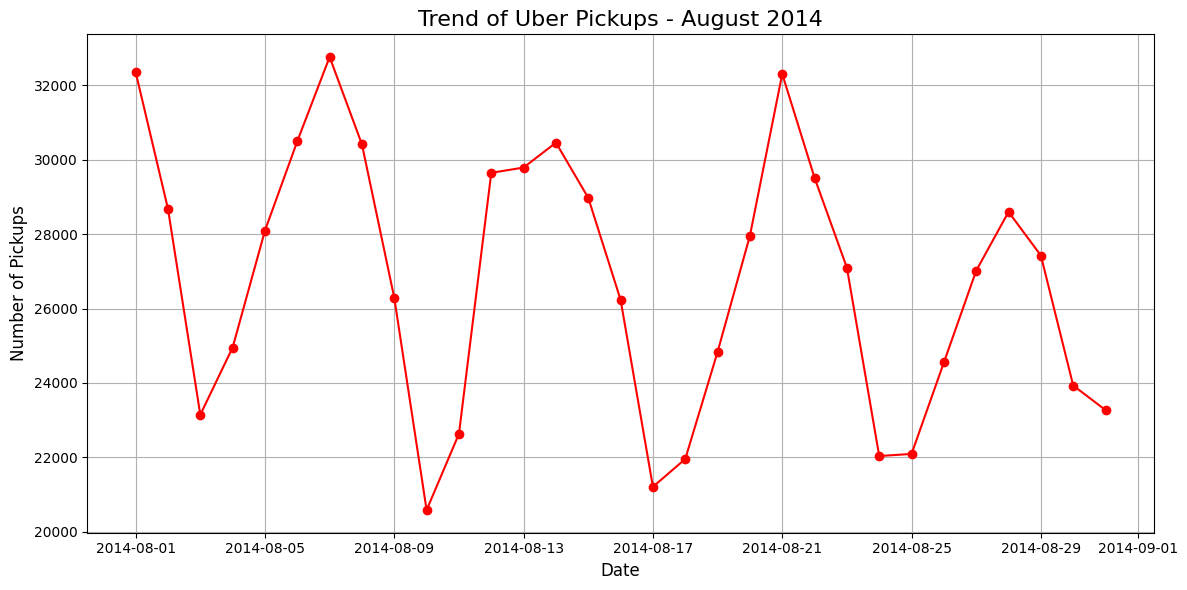

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/content/drive/MyDrive/uber-raw-data-aug14.csv')
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['Date'] = df['Date/Time'].dt.date
daily_pickups = df.groupby('Date').size()
plt.figure(figsize=(12,6))
plt.plot(daily_pickups.index, daily_pickups.values, marker='o', color='red')
plt.title('Trend of Uber Pickups - August 2014', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Pickups', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

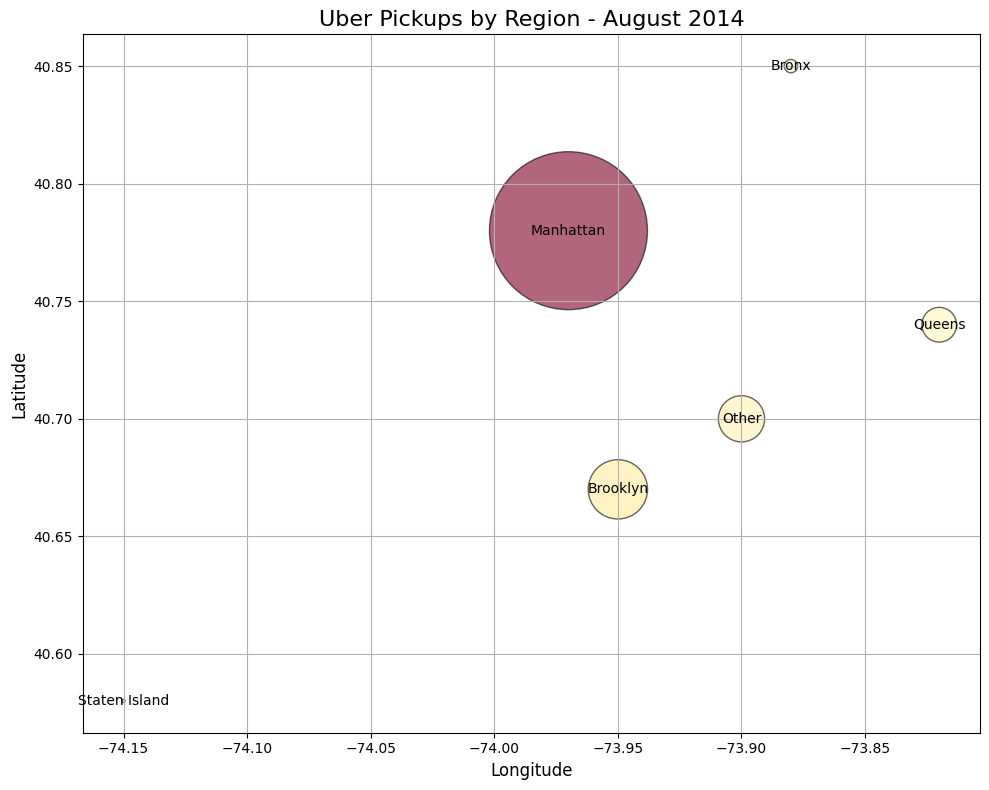

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (example: uber-raw-data-apr14.csv)
df = pd.read_csv('/content/drive/MyDrive/uber-raw-data-aug14.csv')

# Convert 'Date/Time' to datetime (if needed)
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Define approximate region boundaries (simplified version)
def classify_region(lat, lon):
    if 40.70 <= lat <= 40.85 and -74.02 <= lon <= -73.93:
        return 'Manhattan'
    elif 40.57 <= lat <= 40.74 and -74.05 <= lon <= -73.85:
        return 'Brooklyn'
    elif 40.84 <= lat < 40.91 and -73.92 <= lon <= -73.77:
        return 'Bronx'
    elif 40.65 <= lat <= 40.80 and -73.90 <= lon <= -73.70:
        return 'Queens'
    elif 40.48 <= lat <= 40.65 and -74.25 <= lon <= -74.05:
        return 'Staten Island'
    else:
        return 'Other'

# Apply region classification
df['Region'] = df.apply(lambda x: classify_region(x['Lat'], x['Lon']), axis=1)

# Group by region to count total pickups
region_pickups = df.groupby('Region').size().reset_index(name='Pickups')

# Approximate central coordinates for each region (for plotting)
region_centers = {
    'Manhattan': (-73.97, 40.78),
    'Brooklyn': (-73.95, 40.67),
    'Bronx': (-73.88, 40.85),
    'Queens': (-73.82, 40.74),
    'Staten Island': (-74.15, 40.58),
    'Other': (-73.9, 40.7)
}

region_pickups['Lon'] = region_pickups['Region'].map(lambda x: region_centers[x][0])
region_pickups['Lat'] = region_pickups['Region'].map(lambda x: region_centers[x][1])

# Plot bubble chart
plt.figure(figsize=(10,8))
plt.scatter(region_pickups['Lon'], region_pickups['Lat'],
            s=region_pickups['Pickups'] / 50, c=region_pickups['Pickups'],
            cmap='YlOrRd', alpha=0.6, edgecolors='k')

# Add labels
for i, row in region_pickups.iterrows():
    plt.text(row['Lon'], row['Lat'], row['Region'], fontsize=10, ha='center', va='center')

plt.title('Uber Pickups by Region - August 2014', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()
